In [1]:
################################################
###
### test SH decomposition with Hannah organoid data V2
### here mainly testing how to improve the SH fitting by processing the 3D image or 2D spherical grid data
###
################################################

In [1]:
from skimage import measure
import pandas as pd
from skimage.filters import threshold_otsu, rank
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pyshtools as pysh

In [3]:
from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from pyclesperanto_prototype import imshow
import pyclesperanto_prototype as cle
import matplotlib.pyplot as plt

In [4]:
import napari
from napari.utils import nbscreenshot

In [5]:
cle.available_device_names()

['Apple M1 Max']

In [6]:
# For 3D processing, powerful graphics
# processing units might be necessary
cle.select_device('TX')

/Users/jingkui.wang/miniforge3/envs/image_env/lib/python3.9/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with TX in their name. Using Apple M1 Max instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


<Apple M1 Max on Platform: Apple (2 refs)>

In [7]:
### import function https://github.com/gioda/FeARLesS/blob/main/Fearless/utils.py
import pyshtools
import gc
import numpy as np
import os
from vedo import printc, spher2cart, probePoints

#from vedo import Points
import shutil
from sys import exit
#from vedo import spher2cart
#from vedo import printc, spher2cart, probePoints

In [8]:
def samplePoints(vol, expo, N, radiusDiscretisation):
    """Compute sample points."""
    pos = vol.center()
    rmax = vol.diagonalSize()/2

    samplePoints = []
    for th in np.linspace(0, np.pi, N, endpoint=False):
        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):

            # compute sample points
            p = spher2cart(rmax, th, ph)
            # making discretization more dense away from the center
            p_tmp = p / (radiusDiscretisation-1)**expo
            for j in range(radiusDiscretisation):
                SP = pos + p_tmp * (j**expo)
                samplePoints.append(SP)

    del vol
    return np.array(samplePoints)

def confirm(message):
    """
    Ask user to enter Y or N (case-insensitive).

    :return: True if the answer is Y.
    :rtype: bool
    """
    answer = ""
    while answer not in ["y", "n"]:
        answer = input(message).lower()
    return answer == "y"


def pathExists(path):
    if not os.path.exists(path):
        os.makedirs(path, exist_ok=True)
        printc("Directory ", path, " Created ", c='green')
    else:
        printc("Directory ", path, " already exists", c='red')
        if confirm("Should I delete the folder and create a new one [Y/N]? "):
            shutil.rmtree(path)
            os.makedirs(path, exist_ok=True)
            printc("Directory ", path, " Created ", c='green')
        else:
            exit()


def voxelIntensity(vol, expo, N, radiusDiscretisation):
    """Compute voxel intensities."""
    pos = vol.center()
    rmax = vol.diagonalSize()/2

    scalars = []

    for th in np.linspace(0, np.pi, N, endpoint=False):
        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):

            # compute sample points
            p = spher2cart(rmax, th, ph)
            samplePointsTmp = []
            
            # making discretization more dense away from the center
            p_tmp = p / (radiusDiscretisation-1)**expo
            for j in range(radiusDiscretisation):
                SP = pos + p_tmp * (j**expo)
                samplePointsTmp.append(SP)

            # compute intensities
            pb = probePoints(vol, samplePointsTmp)

            del samplePointsTmp

            # making the intensities growing outside the volume according to the gradient
            scalarsTmp = pb.getPointArray()
            nonz = np.nonzero(scalarsTmp)[0]
            if len(nonz) > 2:
                lastNoZeroId = nonz[-1]  # find the last value != 0
                secondlastNoZeroId = nonz[-2]
                # find the last value != 0
                lastNoZero = scalarsTmp[lastNoZeroId]
                secondlastNoZero = scalarsTmp[secondlastNoZeroId]
                dx = lastNoZero - secondlastNoZero

            for i in range(lastNoZeroId+1, len(scalarsTmp)):
                scalarsTmp[i] = scalarsTmp[i-1] + dx
            scalars.append(scalarsTmp.tolist())

            del pb, scalarsTmp

    del vol
    gc.collect()

    # return allIntensitiesMatrix
    return np.array(scalars).reshape((N * N, radiusDiscretisation))


def forwardTransformation(matrixOfIntensities, N, lmax):

    ##############################################

    coeff = matrixOfIntensities

    ##############################################
    # SPHARNM
    allClm = np.zeros((matrixOfIntensities.shape[1], 2, lmax, lmax))
    for j in range(allClm.shape[0]):
        formattedcoeff = np.reshape(coeff[:, j], (N, N))
        SH = pyshtools.SHGrid.from_array(formattedcoeff)
        clm = SH.expand()

        allClm[j, :, :, :] = clm.to_array(lmax=lmax - 1)

    del formattedcoeff, clm, matrixOfIntensities

    return allClm


def inverseTransformations(allClm, allIntensitiesShape, N, lmax):
    """Make inverse SPHARM."""
    from scipy.interpolate import griddata

    aSH_recoMatrix = np.zeros((allIntensitiesShape[0], allIntensitiesShape[1]))

    for j in range(allClm.shape[0]):
        # inverse SPHARM coefficients
        clmCoeffs = pyshtools.SHCoeffs.from_array(allClm[j, :, :, :])
        SH_reco = clmCoeffs.expand(lmax=lmax - 1)
        # grid_reco.plot()
        aSH_reco = SH_reco.to_array()

        ##############################
        pts1 = []
        ll = []
        for ii, long in enumerate(np.linspace(0, 360, num=aSH_reco.shape[1], endpoint=True)):
            for jj, lat in enumerate(np.linspace(90, -90, num=aSH_reco.shape[0], endpoint=True)):
                th = np.deg2rad(90 - lat)
                ph = np.deg2rad(long)
                p = spher2cart(aSH_reco[jj][ii], th, ph)
                pts1.append(p)
                ll.append((lat, long))

        radii = aSH_reco.T.ravel()

        # make a finer grid
        n = N * 1j
        l_min, l_max = np.array(ll).min(axis=0), np.array(ll).max(axis=0)
        grid = np.mgrid[l_max[0]:l_min[0]:n, l_min[1]:l_max[1]:n]
        grid_x, grid_y = grid
        agrid_reco_finer = griddata(ll, radii, (grid_x, grid_y), method='cubic')
        ##############################

        formatted_aSH_reco = np.reshape(agrid_reco_finer, (N * N))

        aSH_recoMatrix[:, j] = formatted_aSH_reco

    del formatted_aSH_reco, agrid_reco_finer, grid_x, grid_y, grid

    return aSH_recoMatrix


In [9]:
from sys import argv, exit
import numpy as np
import pyshtools

from vedo import printc, load, spher2cart, mag, ProgressBar, Points, write
from vedo import *

from skimage.io import imread
from skimage.io import imsave
#from skimage import filters
#from skimage import morphology
#from pyclesperanto_prototype import imshow
#import pyclesperanto_prototype as cle
#import matplotlib.pyplot as plt

#from scipy.interpolate import griddata

In [10]:
def computeCLM(mesh, rmax, N, x0):
    """Compute CLM."""
    # cast rays from the center and find intersections
    agrid, pts = [], []
    for th in np.linspace(0, np.pi, N, endpoint=False):
        lats = []
        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):
            p = spher2cart(rmax, th, ph)
            intersections = mesh.intersect_with_line(x0, x0 + p)
            if len(intersections):
                value = mag(intersections[0]-x0)
                lats.append(value)
                pts.append(intersections[0])
            else:
                lats.append(rmax)
                # lats.append(0)
                pts.append(p)
        agrid.append(lats)
    agrid = np.array(agrid)

    grid = pyshtools.SHGrid.from_array(agrid)
    clm = grid.expand()
    # grid_reco = clm.expand(lmax=lmax)  # cut "high frequency" components

    return clm


In [11]:
from skimage import measure
import pandas as pd
from skimage.filters import threshold_otsu, rank
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from vedo import printc, load, ProgressBar
#from utils import pathExists, voxelIntensity
import numpy as np
import gc
#import matplotlib
#matplotlib.use('Agg')  # Use Agg backend for non-interactive plotting

import matplotlib.pyplot as plt

In [54]:
#CPoutDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/RA_competence/images_data/d4_WT"
#WTDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/RA_competence/images_data/d4_WT" 
inputDir = "/Volumes/groups/tanaka/People/current/Hannah/RawImagesVienna/M44_OlympusSD/211208-11_HM1-extended-compTC/Isotropic/Isotropic_stainA_RAd2_forSH"
fileName = '211209_d3_RAd2_D2_52_01_isotropic'
#fileName = '211210_d6_RAd2_D2_49_01_isotropic'

inputDir = "/Volumes/groups/tanaka/People/current/jiwang/projects/RA_competence/images_data/test_WTd6"
fileName = '20220727_d6_10x_RA-18h_E2_121_1981_isotropic'
#fileName = "20220726_d4_10x_RA-18h_E2_121_1745_isotropic"
#fileName = '241023_10x_d4-2umZ_4-PS-WG_RA_FA2-Px6_F9_95_01_isotropic'
#fileName = '211209_d3_RAd2_D2_51_01_isotropic'
#fileName = '211210_d6_RAd2_D2_49_01_isotropic'

In [55]:
#DataPath = '/Users/jingkui.wang/workspace/imp/image_analysis/S-BIAD441/limbs/limbs-noFlank/'
path_results = 'res/' \
        + 'test_organoid_timepoints' + '/'
outDir = path_results

print(outDir)

res/test_organoid_timepoints/


In [56]:
# C1 = Nkx6.1 (not important now) # C2 = Shh with a bad stain quality (ignore), #C3 = FoxA2 #C4 = Dapi
mask = imread(os.path.join(inputDir, str(fileName + "_C4_CystMask.tiff"))) # mask segmeted cysts
C3 = imread(os.path.join(inputDir, str(fileName + "_C3.tif"))) # FoxA2, nuclei
#C2 = imread(os.path.join(inputDir, str(fileName + "_C2.tif"))) # Pax6, nuclei
C4 = imread(os.path.join(inputDir, str(fileName + "_C4.tif"))) # Dapi, nuclei

#C3 = C3 / np.quantile(C3, 0.95)
#C2 = C2 / np.quantile(C2, 0.95)
#C4 = C4 / np.quantile(C4, 0.95)

In [57]:
from skimage import measure
import pandas as pd
from skimage.morphology import disk
from skimage.filters import threshold_otsu as filter_otsu
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from vedo import printc, load, ProgressBar
#from utils import pathExists, voxelIntensity
import numpy as np
## try to add the local maximal detection
from scipy import ndimage as ndi
from skimage.morphology import disk
from skimage.filters import rank
from skimage.feature import peak_local_max
#from skimage.feature import peak_local_max
import pyclesperanto_prototype as cle
#from skimage.io import imread, imshow
from skimage.filters import gaussian 
import matplotlib.pyplot as plt
#from napari_segment_blobs_and_things_with_membranes import threshold_otsu, split_touching_objects
import napari_segment_blobs_and_things_with_membranes as nsbatwm
import napari_simpleitk_image_processing as nsitk

from skimage.io import imread
from skimage import data
from pyclesperanto_prototype import imshow

import gc
from itertools import chain
# define nones functions
nones = lambda n: [None for _ in range(n)]

In [58]:
labels_mask, nb_cyst = measure.label(mask, return_num = True)

In [59]:
nb_cyst

29

In [60]:
## view the whole image with napari
#viewer = napari.Viewer()

# show images
#viewer.add_image(cle.pull(C3))
#viewer.add_image(cle.pull(C4))
#viewer.add_labels(cle.pull(labels_mask))

In [61]:
## specify SH parameters
N = 250
lmax = 100
radiusDiscretisation = 50
expo = 1.0

In [62]:
cyst_index = np.where(labels_mask == 2)
cyst_index[0].size
#genotype_wt = C3[cyst_index]
#genotype_ko = C2[cyst_index]

40980

In [63]:
col_names =  [['image', 'cyst_index', 'cyst_size', 'cyst_r', 'nb_local_max', 'nb_segmentedObj'], 
              ['power_per_lm_'+i for i in map(str, range(lmax+1))], 
              ['power_per_l_'+i for i in map(str, range(lmax+1))], 
              ['power_per_dlogl_'+i for i in map(str, range(lmax+1))]
             ]
col_names = list(chain(*col_names))

outDir

'res/test_organoid_timepoints/'

cyst size in voxels -- 13152


/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_74337/3976048475.py:32: UserWarning: res/test_organoid_timepoints/20220727_d6_10x_RA-18h_E2_121_1981_isotropic_cyst_2_channel_FoxA2_16.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)


324.19328493903026


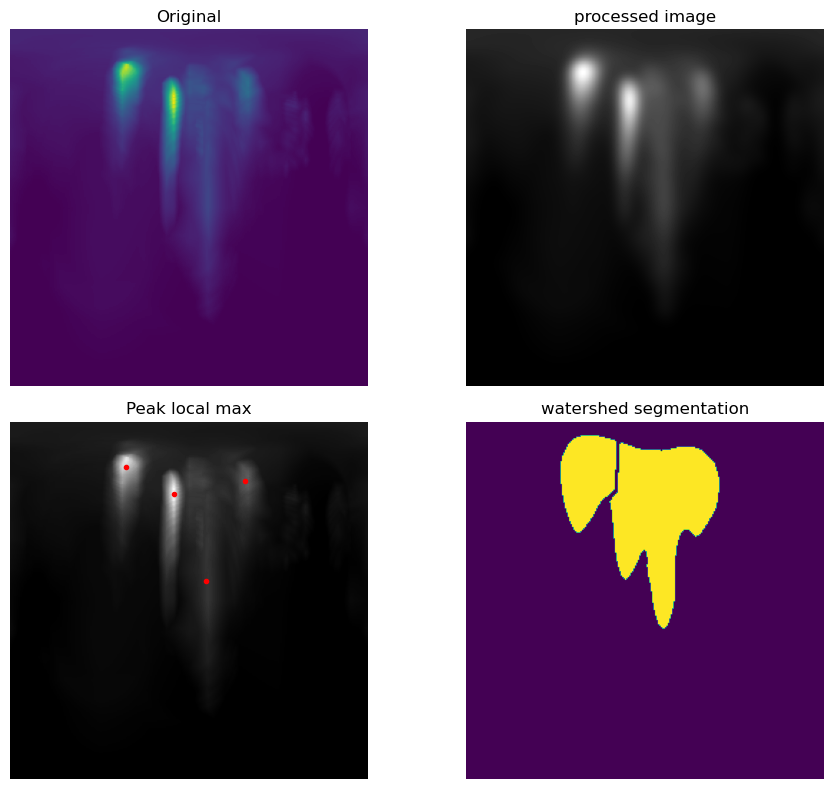

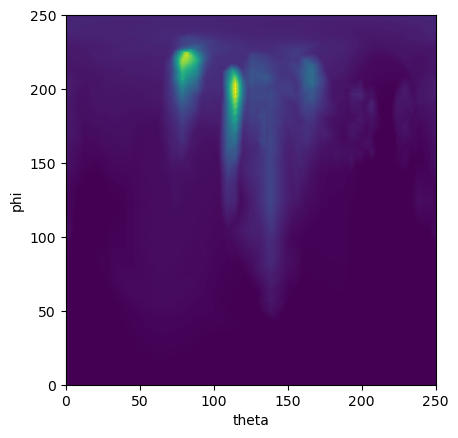

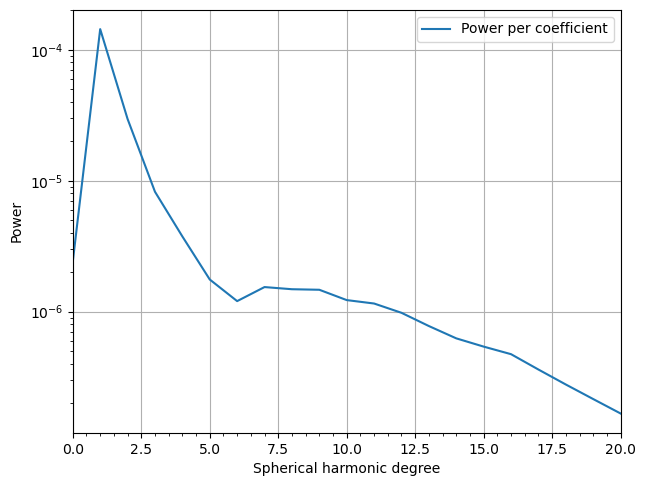

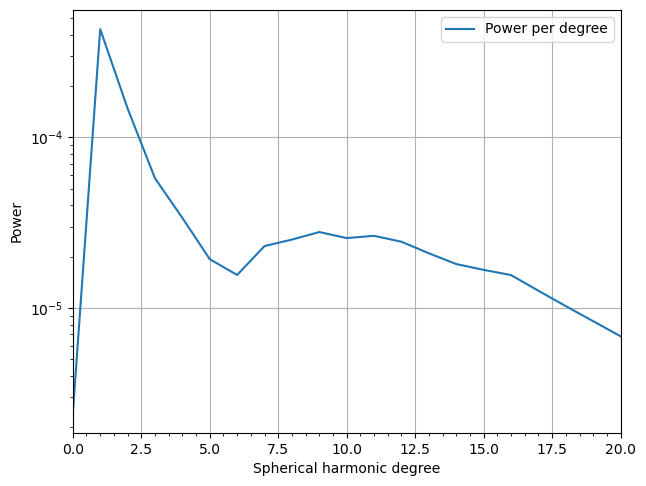

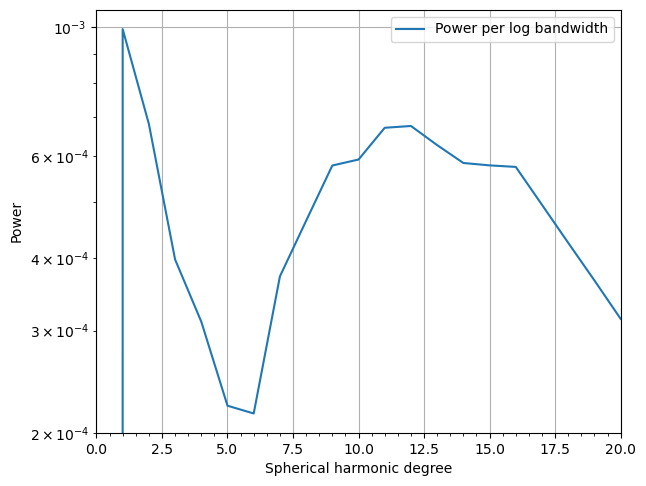

In [68]:
i = 16
plot_napari = False
#plot_napari = True

cyst_select = np.where(labels_mask == i)
print("cyst size in voxels -- " + str(cyst_select[0].size))
cyst_index = i

if cyst_select[0].size > 500: # orgnoid must > 100
    # find the boundary of the orgnoid
    
    [z, rows, columns] = np.where(labels_mask == cyst_index)
    z1 = min(z)
    z2 = max(z)
    row1 = min(rows)
    row2 = max(rows)
    col1 = min(columns)
    col2 = max(columns)
    
    df = pd.DataFrame(columns = col_names)
    
    # crop the orgnoid and save foxa2 and dapi
    xx = np.where(labels_mask == cyst_index, C3, 0)
    newImage_foxa2 = xx[z1:z2, row1:row2, col1:col2]
    xx = None
                    
    xx = np.where(labels_mask == cyst_index, C4, 0)
    newImage_dapi = xx[z1:z2, row1:row2, col1:col2]
    
    cutoff_foxa2 = threshold_otsu(newImage_foxa2)
    
    imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)
    imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")), newImage_dapi)
                    
    #gc.collect()
    # show images in napari
    
    if plot_napari:
        viewer = napari.Viewer()
        viewer.add_image(cle.pull(newImage_foxa2))
        viewer.add_image(cle.pull(newImage_dapi))
                    
    # reload the dapi and foxa2 using vedo
    vol_foxa2 = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")))
    vol_dapi = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")))
                
    # the center and radius of organoid
    pos = vol_dapi.center()
    rmax = vol_dapi.diagonalSize()/2
                
    # Compute voxel intensities
    scalars = []
    for th in np.linspace(0, np.pi, N, endpoint=False):
        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):
            # compute sample points
            p = spher2cart(rmax, th, ph)
            
            samplePointsTmp = []
            # making discretization more dense away from the center
            p_tmp = p / (radiusDiscretisation-1)**expo
                        
            for j in range(radiusDiscretisation):
                SP = pos + p_tmp * (j**expo)
                samplePointsTmp.append(SP)

            # compute intensities
            pb = probePoints(vol_foxa2, samplePointsTmp)

            scalarsTmp = pb.getPointArray()
            nonz = np.nonzero(scalarsTmp)[0]
            scalarsTmp_nonz = scalarsTmp[nonz]
            
            scalars.append(scalarsTmp_nonz.max())
            #scalars.append(scalarsTmp_nonz.mean())
            #scalars.append(np.median(scalarsTmp_nonz))
                         
            #del pb, scalarsTmp, samplePointsTmp, p, p_tmp
            #pb, scalarsTmp, samplePointsTmp, p, p_tmp, SP = nones(6)
            #gc.collect()

    #del th, ph
    th, ph = nones(2)
                    
    matrixOfIntensities = np.array(scalars)
    formattedcoeff = np.reshape(matrixOfIntensities, (N, N))
    
    ## smoothing the spherical grid for local maximum detection
    #formattedcoeff = gaussian(formattedcoeff, sigma=2, preserve_range=True)
    preprocessed = gaussian(formattedcoeff, sigma=4, preserve_range=True)
    ## find the cutoff of FoxA2
    binary = nsbatwm.threshold_otsu(preprocessed)
    
    #imshow(binary)
    split_objects = nsbatwm.split_touching_objects(binary, sigma=3.5)
    #imshow(split_objects)
    
    #touching_labels = nsitk.touching_objects_labeling(binary, sigma=6)
    
    mask_grid, nb_labels = measure.label(split_objects, return_num = True)
    
    cutoff_foxa2 = filter_otsu(preprocessed)
    print(cutoff_foxa2)
    
    coordinates = peak_local_max(preprocessed, threshold_abs=cutoff_foxa2, min_distance=10)
    
    #cutoff_foxa2 = filter_otsu(preprocessed)
    #print(cutoff_foxa2)
    #coordinates = peak_local_max(preprocessed, threshold_abs=cutoff_foxa2, min_distance=10)
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    ax = axes.ravel()
    
    
    ax[0].imshow(formattedcoeff)
    ax[0].axis('off')
    ax[0].set_title('Original')

    ax[1].imshow(preprocessed, cmap=plt.cm.gray)
    ax[1].axis('off')
    ax[1].set_title('processed image')

    ax[2].imshow(formattedcoeff, cmap=plt.cm.gray)
    ax[2].autoscale(False)
    ax[2].plot(coordinates[:, 1], coordinates[:, 0], 'r.')
    ax[2].axis('off')
    ax[2].set_title('Peak local max')

    ax[3].imshow(split_objects)
    ax[3].autoscale(False)
    #ax[3].plot(coordinates[:, 1], coordinates[:, 0], 'r.')
    ax[3].axis('off')
    ax[3].set_title('watershed segmentation')
    
    fig.tight_layout()

    plt.savefig(os.path.join(outDir, str(fileName + "_" + str(cyst_index) +  "locaMaximum_watershedSegmentation.pdf")))
    #plt.show()

    
    # remove the mean to reduce the l=0 contribution
    #formattedcoeff_norm = formattedcoeff - formattedcoeff.mean()
    formattedcoeff_norm = (formattedcoeff - formattedcoeff.mean())/np.var(formattedcoeff)
    
    SH = pyshtools.SHGrid.from_array(formattedcoeff_norm, grid = "DH")
    clm = SH.expand(lmax_calc= lmax)
    #grid_reco = clm.expand(lmax=lmax).to_array()  # cut "high frequency" components
    grid = clm.expand(lmax = lmax)
    
    
    fig, ax = plt.subplots(1, 1)
    ax.imshow(formattedcoeff, extent=(0, N, 0, N))
    ax.set(xlabel='theta', ylabel='phi')
    #plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity.pdf")))
    plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity_" + str(cyst_index)+".pdf")))
    
    fig, ax = clm.plot_spectrum(show=False, lmax = 20, convention = 'power', unit = "per_lm")
    plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_lm_" + str(cyst_index)+".pdf")))
                        
    fig, ax = clm.plot_spectrum(show=False, lmax = 20, convention = 'power', unit = "per_l")
    plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_l_" + str(cyst_index)+ ".pdf")))
    
    fig, ax = clm.plot_spectrum(show=False, lmax = 20, convention = 'power', unit = "per_dlogl")
    plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_dlogl_" + str(cyst_index)+ ".pdf")))
                        4
    #fig, ax = clm.plot_spectrum2d(show=False, lmax = 10)
    #plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_2d_per_l_m_"+ str(cyst_index)+".pdf")))
    
    coefs = clm.spectrum(lmax = 50, convention = 'power', unit = "per_l")

    #plt.figure(figsize=(9, 3))
    #plt.plot(coefs/np.sum(coefs))
    #plt.axhline(y = 1.0/len(coefs), color = 'r', linestyle = '-') 
    #plt.yscale('log')

    #cutoff_foxa2 = threshold_otsu(formattedcoeff)
    #preprocessed = gaussian(formattedcoeff, sigma=4, preserve_range=True)

    # save the SH power
    df.loc[len(df)] =  list(chain([fileName, cyst_index, cyst_select[0].size, rmax, len(coordinates), nb_labels],
                                          clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm"),
                                          clm.spectrum(lmax = lmax, convention = 'power', unit = "per_l"),
                                 clm.spectrum(lmax = lmax, convention = 'power', unit = "per_dlogl")))
    
    
    df.to_csv(os.path.join(outDir, str("SHspectrum_power_" + fileName + "_" + str(cyst_index) + ".csv")), index=True, header=True)
    
    del df
    

In [28]:
len(coordinates)

9

In [41]:
split_objects
touching_labels = nsitk.touching_objects_labeling(binary)
touching_labels
mask, nb_labels = measure.label(touching_labels, return_num = True)

In [42]:
nb_labels

10

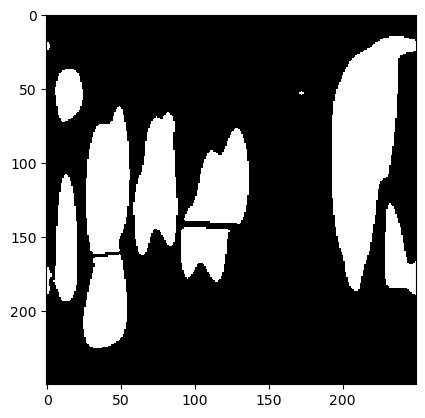

392.2566544273848


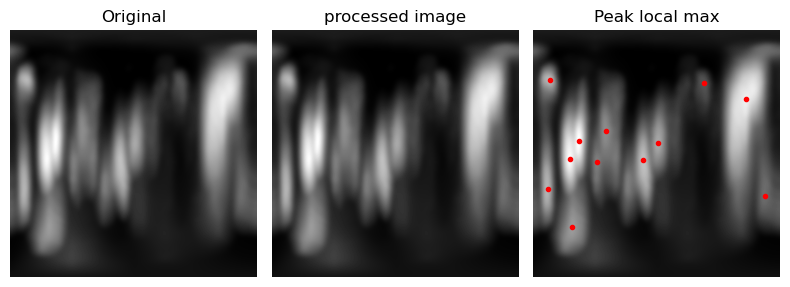

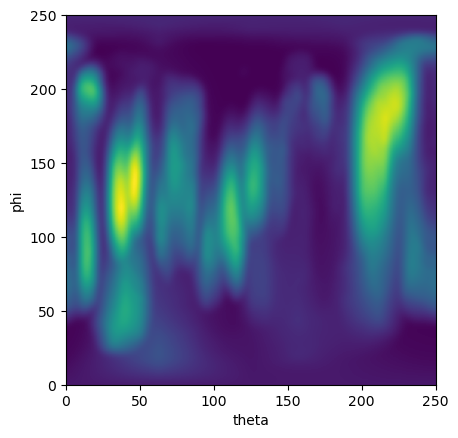

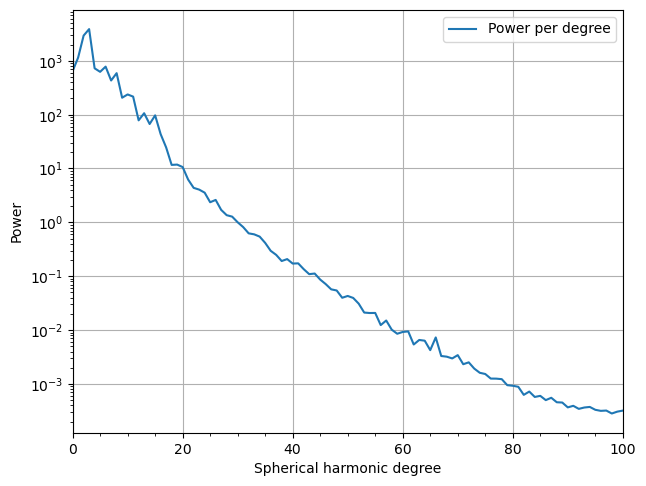

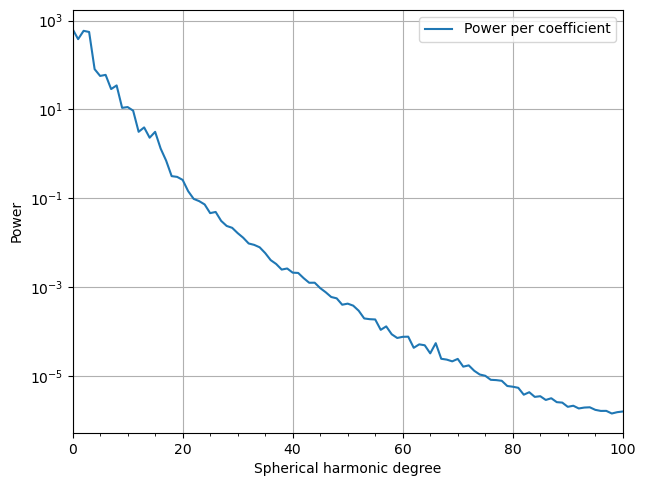

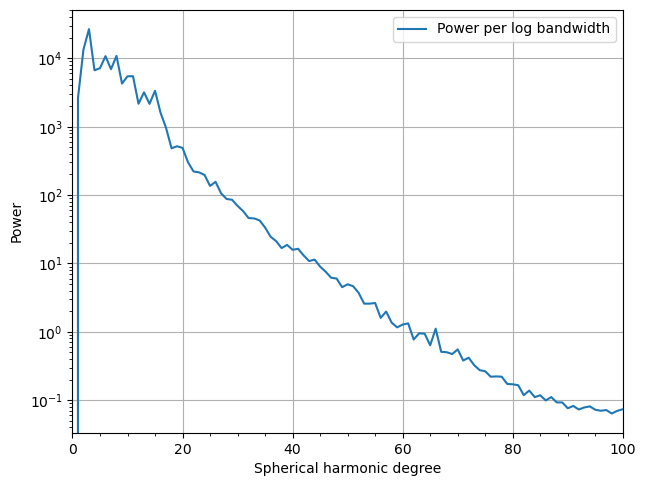

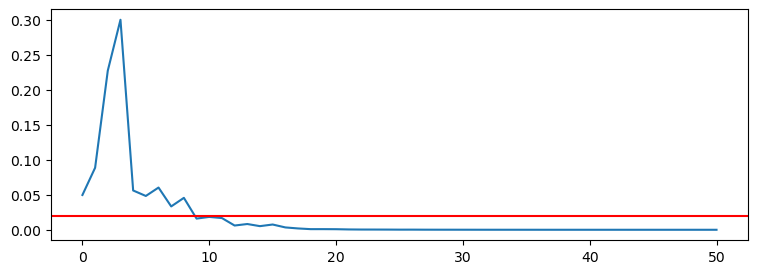

In [219]:
matrixOfIntensities = np.array(scalars)

formattedcoeff = np.reshape(matrixOfIntensities, (N, N))
preprocessed = gaussian(formattedcoeff, sigma=2, preserve_range=True)

binary = threshold_otsu(preprocessed)

#imshow(binary)
split_objects = split_touching_objects(binary, sigma=6)
imshow(split_objects)

cutoff_foxa2 = filter_otsu(preprocessed)
print(cutoff_foxa2)
    
coordinates = peak_local_max(preprocessed, threshold_abs=cutoff_foxa2, min_distance=10)

#footprint = disk(4)
# using filtering to smooth spherical grids
#formattedcoeff = rank.mean(formattedcoeff, footprint=footprint)
#formattedcoeff = filters.gaussian(formattedcoeff, sigma=0.5)
#cutoff_foxa2 = threshold_otsu(formattedcoeff)
#preprocessed = gaussian(formattedcoeff, sigma=4, preserve_range=True)

## find the cutoff of FoxA2
#cutoff_foxa2 = threshold_otsu(preprocessed)
#print(cutoff_foxa2)
#coordinates = peak_local_max(preprocessed, threshold_abs=cutoff_foxa2, min_distance=10)

#local_maxima_image = cle.detect_maxima_box(preprocessed)
#local_maxima_image


#formattedcoeff = formattedcoeff > cutoff_foxa2

# remove the mean to reduce the l=0 contribution
formattedcoeff = preprocessed

formattedcoeff_norm = formattedcoeff - formattedcoeff.mean()
#formattedcoeff_norm = (formattedcoeff - formattedcoeff.mean())/np.var(formattedcoeff)
#formattedcoeff_norm = formattedcoeff 
# image_max is the dilation of im with a 20*20 structuring element
# It is used within peak_local_max function
#image_max = ndi.maximum_filter(preprocessed, size=10, mode='constant')
# Comparison between image_max and im to find the coordinates of local maxima
#coordinates = peak_local_max(image_max, min_distance=10, exclude_border = True, threshold_abs=cutoff_foxa2)

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(formattedcoeff, cmap=plt.cm.gray)
ax[0].axis('off')
ax[0].set_title('Original')

ax[1].imshow(preprocessed, cmap=plt.cm.gray)
ax[1].axis('off')
ax[1].set_title('processed image')

ax[2].imshow(formattedcoeff, cmap=plt.cm.gray)
ax[2].autoscale(False)
ax[2].plot(coordinates[:, 1], coordinates[:, 0], 'r.')
ax[2].axis('off')
ax[2].set_title('Peak local max')

fig.tight_layout()

plt.show()


#rank.mean_percentile()
fig, ax = plt.subplots(1, 1)
ax.imshow(formattedcoeff_norm, extent=(0, N, 0, N))
ax.set(xlabel='theta', ylabel='phi')
    

SH = pyshtools.SHGrid.from_array(formattedcoeff_norm, grid = "DH")
clm = SH.expand(lmax_calc= lmax)
grid_reco = clm.expand(lmax=lmax).to_array()  # cut "high frequency" components
grid = clm.expand(lmax = lmax)
                    
lmax = 100
fig, ax = clm.plot_spectrum(show=False, lmax = lmax, convention = 'power', unit = "per_l", yscale='log', xscale = 'lin')
#fig, ax = clm.plot_spectrum(show=False, lmax = lmax, convention = 'l2norm', unit = "per_l")
#fig, ax = clm.plot_spectrum(show=False, lmax = 20, convention = 'energy', unit = "per_l")
fig, ax = clm.plot_spectrum(show=False, lmax = lmax, convention = 'power', unit = "per_lm", yscale='log', xscale = 'lin')
fig, ax = clm.plot_spectrum(show=False, lmax = lmax, convention = 'power', unit = "per_dlogl", yscale='log', xscale = 'lin')


coefs = clm.spectrum(lmax = 50, convention = 'power', unit = "per_l")

plt.figure(figsize=(9, 3))
plt.plot(coefs/np.sum(coefs))
plt.axhline(y = 1.0/len(coefs), color = 'r', linestyle = '-') 
#plt.yscale('log')


#coefs = clm.spectrum(lmax = 50, convention = 'power', unit = "per_dlogl")
#coefs/np.sum(coefs)

In [80]:
#clm_orth = clm.convert(normalization = 'ortho')
#clm_orth.spectrum(lmax = 50, convention = 'power', unit = "per_l")
#clm_orth.plot_spectrum(show=False, lmax = 20, convention = 'power', unit = "per_l")

In [53]:
frac = coefs/np.sum(coefs)
cumulative_sum = np.cumsum(frac)
frac

array([2.23120743e-02, 1.12200401e-01, 1.82822715e-01, 8.70314485e-02,
       7.95012367e-02, 4.98213424e-02, 8.92353245e-02, 8.33966813e-02,
       5.79307415e-02, 4.20403590e-02, 4.78503078e-02, 2.22592060e-02,
       3.55672554e-02, 1.61281530e-02, 1.39062502e-02, 1.37919616e-02,
       5.80448198e-03, 9.05114992e-03, 4.29079945e-03, 5.28980451e-03,
       3.25560010e-03, 2.61673273e-03, 1.82216059e-03, 2.22909067e-03,
       1.71343436e-03, 2.07810520e-03, 1.47191675e-03, 7.23485630e-04,
       8.71382185e-04, 3.28240580e-04, 4.42408676e-04, 2.81247045e-04,
       2.89912634e-04, 1.99582933e-04, 2.07598315e-04, 1.44566703e-04,
       1.39895499e-04, 1.22941492e-04, 1.23746754e-04, 7.27772177e-05,
       1.01629091e-04, 5.57070386e-05, 4.74695186e-05, 6.12551976e-05,
       4.62466808e-05, 5.72830822e-05, 5.74322619e-05, 6.23046438e-05,
       4.95039662e-05, 5.27088732e-05, 4.19398707e-05])

In [54]:
cumulative_sum


array([0.02231207, 0.13451248, 0.31733519, 0.40436664, 0.48386788,
       0.53368922, 0.62292454, 0.70632122, 0.76425196, 0.80629232,
       0.85414263, 0.87640184, 0.91196909, 0.92809725, 0.9420035 ,
       0.95579546, 0.96159994, 0.97065109, 0.97494189, 0.98023169,
       0.98348729, 0.98610403, 0.98792619, 0.99015528, 0.99186871,
       0.99394682, 0.99541873, 0.99614222, 0.9970136 , 0.99734184,
       0.99778425, 0.9980655 , 0.99835541, 0.99855499, 0.99876259,
       0.99890716, 0.99904705, 0.99917   , 0.99929374, 0.99936652,
       0.99946815, 0.99952386, 0.99957133, 0.99963258, 0.99967883,
       0.99973611, 0.99979354, 0.99985585, 0.99990535, 0.99995806,
       1.        ])

In [29]:
np.max(formattedcoeff_norm), np.min(formattedcoeff_norm)

(2034.2533691480457, -95.21083911674145)

In [132]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3
reg = LinearRegression().fit(X, y)
reg.score(X, y)
reg.coef_
reg.intercept_
reg.predict(np.array([[3, 5]]))

array([16.])

In [134]:
X,y

(array([[1, 1],
        [1, 2],
        [2, 2],
        [2, 3]]),
 array([ 6,  8,  9, 11]))

In [ ]:
### test localized windows to further test the spectrum

In [109]:
grid_global = pysh.SHGrid.from_array(formattedcoeff_norm)
latgrid, longrid = np.meshgrid(grid_global.lats(), grid_global.lons(), indexing='ij')

window_1 = (-60 < latgrid) & (latgrid < 60) & (0 < longrid) & (longrid < 360)
window_2 = (-60 < latgrid) & (latgrid < 60) & (0 < longrid) & (longrid < 180)
window_3 = (-60 < latgrid) & (latgrid < 60) & (180 < longrid) & (longrid < 360)


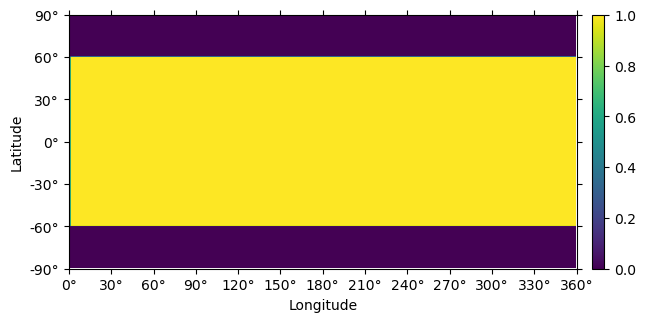

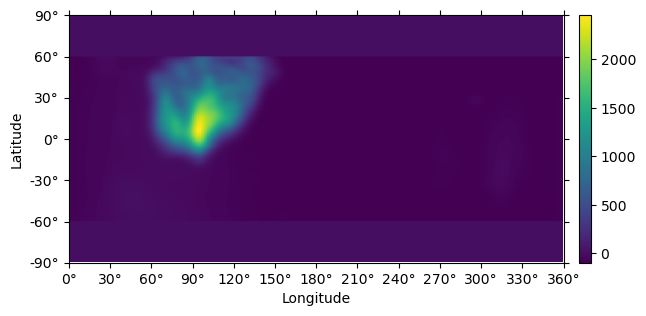

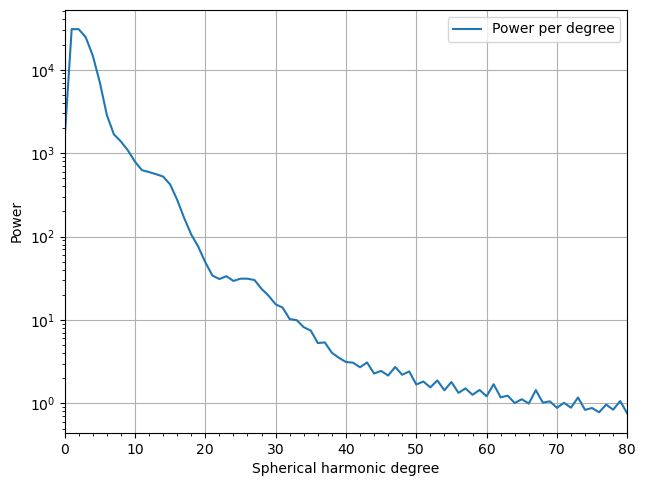

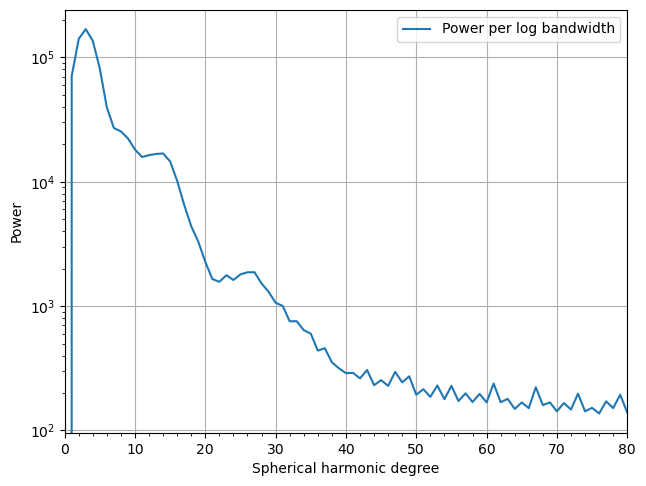

In [113]:
grid_window = pysh.SHGrid.from_array(window_1.astype(np.float64))
fig, ax = grid_window.plot(colorbar='right', show=False)

coeffs_window = grid_window.expand()
power_window = coeffs_window.spectrum()
grid_local = pysh.SHGrid.from_array(formattedcoeff_norm) * grid_window
grid_local.plot(colorbar='right', show=False)
coeffs_local = grid_local.expand()
coeffs_local.plot_spectrum(unit='per_l', show=False, lmax  = lmax, )
coeffs_local.plot_spectrum(unit='per_dlogl', show=False, lmax  = lmax)

power_local = coeffs_local.spectrum()

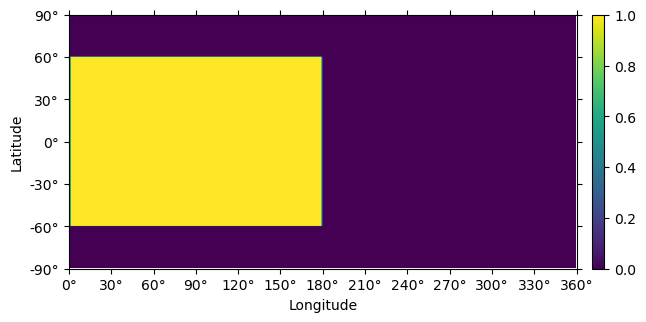

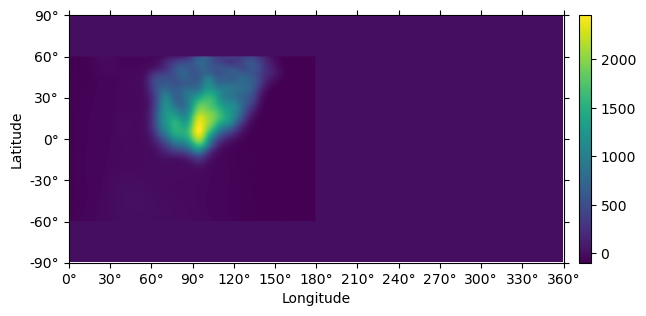

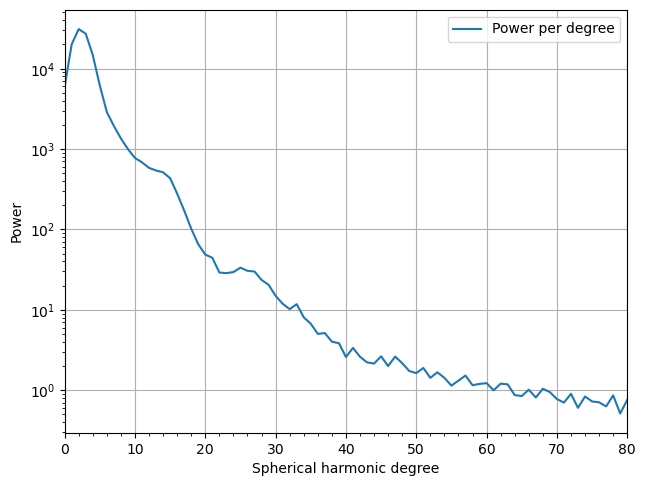

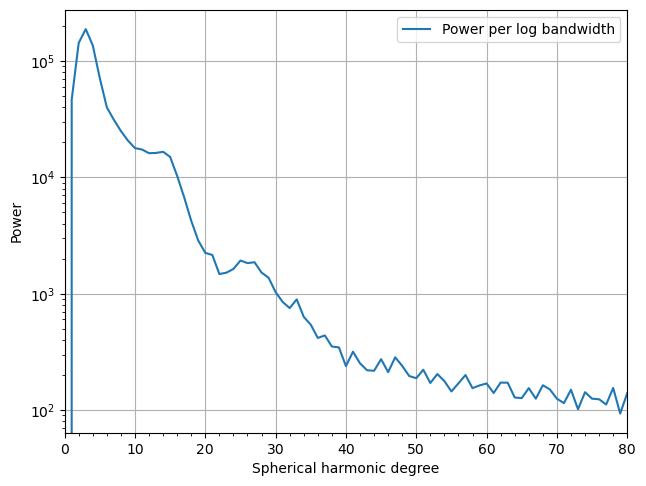

In [114]:
grid_window = pysh.SHGrid.from_array(window_2.astype(np.float64))
fig, ax = grid_window.plot(colorbar='right', show=False)
coeffs_window = grid_window.expand()

power_window = coeffs_window.spectrum()
grid_local = pysh.SHGrid.from_array(formattedcoeff_norm) * grid_window
grid_local.plot(colorbar='right', show=False)
coeffs_local = grid_local.expand()

coeffs_local.plot_spectrum(unit='per_l', show=False, lmax  = lmax)
coeffs_local.plot_spectrum(unit='per_dlogl', show=False, lmax  = lmax)

power_local = coeffs_local.spectrum()

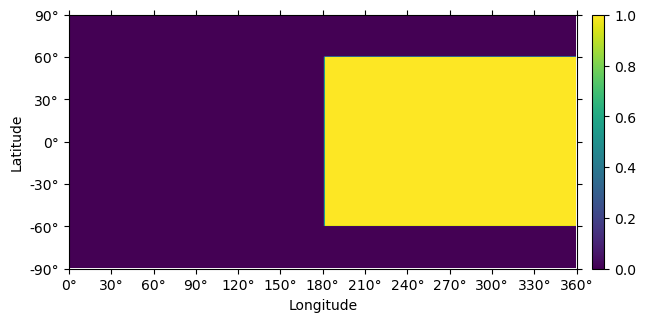

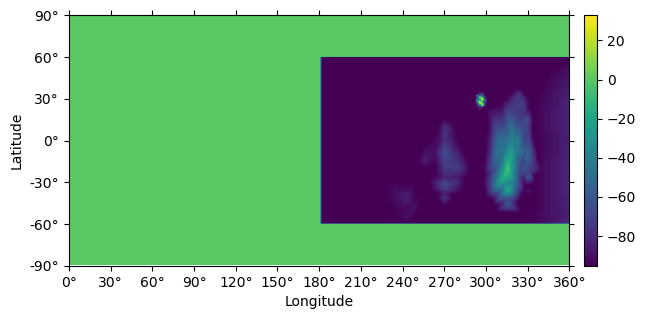

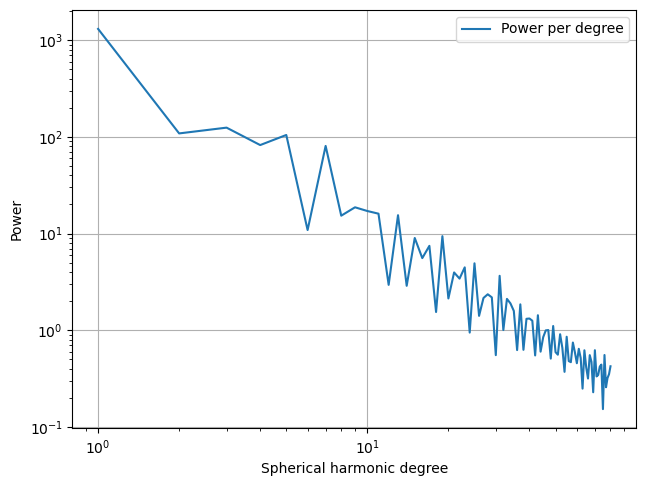

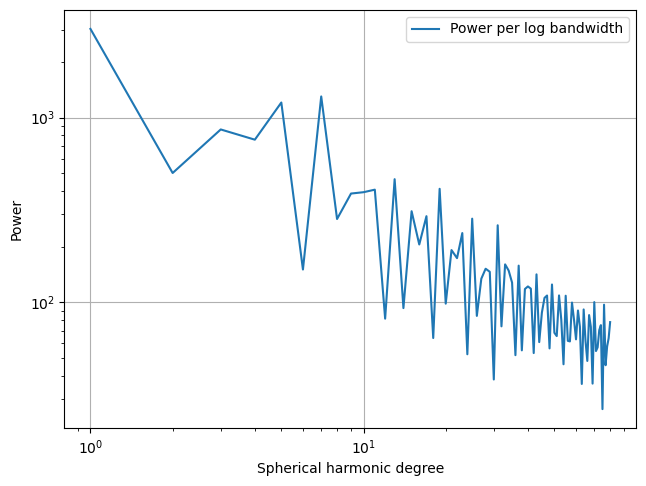

In [136]:
grid_window = pysh.SHGrid.from_array(window_3.astype(np.float64))
fig, ax = grid_window.plot(colorbar='right', show=False)

power_window = coeffs_window.spectrum()
grid_local = pysh.SHGrid.from_array(formattedcoeff_norm) * grid_window
grid_local.plot(colorbar='right', show=False)
coeffs_local = grid_local.expand()
coeffs_local.plot_spectrum(unit='per_l', show=False, lmax  = lmax, xscale='log')
coeffs_local.plot_spectrum(unit='per_dlogl', show=False, lmax  = lmax, xscale='log')

power_local = coeffs_local.spectrum()

In [51]:
pos = vol_dapi.center()
rmax = vol_dapi.diagonalSize()/2
pos, rmax, N, radiusDiscretisation

(array([29., 30., 26.]), 49.16299421312742, 250, 50)

In [57]:
s = Sphere()
c = Cube()
p = Paraboloid()
show(s, c, at=[0, 1], shape=(3,1))
#show(p, at=2, interactive=)

Error in show(): multiple renderings not supported in notebooks.


In [63]:
mesh = Sphere(pos=pos, r=rmax, c='r5', res=24)
show(vol_foxa2).close()
#show(vol_obj, arrs+arrs_pts_probe, N=2, axes=1).close()

In [65]:
show(vol_dapi).close()

In [66]:
scalars = []

In [67]:
np.linspace(0, np.pi, N, endpoint=False);
np.linspace(0, 2*np.pi, N, endpoint=False);
th = np.linspace(0, np.pi, N, endpoint=False)[100]
ph = np.linspace(0, 2*np.pi, N, endpoint=False)[20]
th, ph

(1.2566370614359172, 0.5026548245743669)

In [68]:
p = spher2cart(rmax, th, ph)
p,pos

(array([40.97328392, 22.52525345, 15.19220071]), array([29., 30., 26.]))

In [54]:
p_tmp = p / (radiusDiscretisation-1)**expo

samplePointsTmp = []
for j in range(radiusDiscretisation):
    SP = pos + p_tmp * (j**expo) # pos is the center, 
    samplePointsTmp.append(SP)

len(samplePointsTmp), p, p_tmp, (radiusDiscretisation-1)**expo

(50,
 array([40.97328392, 22.52525345, 15.19220071]),
 array([0.83618947, 0.45969905, 0.31004491]),
 49.0)

In [55]:
samplePointsTmp;

In [56]:
pb = probePoints(vol_foxa2, samplePointsTmp)
#del samplePointsTmp
scalarsTmp = pb.getPointArray()
scalarsTmp

array([452, 495, 489, 464, 467, 474, 459, 443, 436, 420, 422, 428, 413,
       407, 385, 377, 375, 378, 377, 352, 326, 323, 308, 284, 285, 284,
       277, 267, 261, 245,  57,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
      dtype=uint16)

In [57]:
scalarsTmp = pb.getPointArray()

nonz = np.nonzero(scalarsTmp)[0]
scalarsTmp;
nonz

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [58]:
lastNoZeroId = nonz[-1]  # find the last value != 0
secondlastNoZeroId = nonz[-2]
lastNoZeroId, secondlastNoZeroId

(30, 29)

In [59]:
lastNoZero = scalarsTmp[lastNoZeroId]
secondlastNoZero = scalarsTmp[secondlastNoZeroId]
dx = lastNoZero - secondlastNoZero
lastNoZero,secondlastNoZero

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_8819/307586485.py:3: RuntimeWarning: overflow encountered in scalar subtract
  dx = lastNoZero - secondlastNoZero


(57, 245)

In [60]:
scalarsTmp.max().tolist()

495

In [72]:
N = 200; radiusDiscretisation = 50

In [73]:
#scalarsTmp.max()

In [69]:
"""Compute voxel intensities."""
scalars = []
for th in np.linspace(0, np.pi, N, endpoint=False):
    for ph in np.linspace(0, 2*np.pi, N, endpoint=False):
        
        # compute sample points
        p = spher2cart(rmax, th, ph)
        
        samplePointsTmp = []
        # making discretization more dense away from the center
        p_tmp = p / (radiusDiscretisation-1)**expo
        for j in range(radiusDiscretisation):
            SP = pos + p_tmp * (j**expo)
            samplePointsTmp.append(SP)

        # compute intensities
        pb = probePoints(vol_foxa2, samplePointsTmp)
        
        del samplePointsTmp

        # making the intensities growing outside the volume according to the gradient
        scalarsTmp = pb.getPointArray()
        #nonz = np.nonzero(scalarsTmp)[0]
        #print(scalarsTmp)
        
        #if len(nonz) > 2:
        #    lastNoZeroId = nonz[-1]  # find the last value != 0
        #    secondlastNoZeroId = nonz[-2]
        #    # find the last value != 0
        #    lastNoZero = scalarsTmp[lastNoZeroId]
        #    secondlastNoZero = scalarsTmp[secondlastNoZeroId]
        #    dx = lastNoZero - secondlastNoZero

        #for i in range(lastNoZeroId+1, len(scalarsTmp)):
        #    scalarsTmp[i] = scalarsTmp[i-1] + dx
        
        scalars.append(scalarsTmp.max())
        del pb, scalarsTmp

    #del vol
    #gc.collect()

    # return allIntensitiesMatrix
    #return np.array(scalars).reshape((N * N, radiusDiscretisation))

In [71]:
len(scalars)

62500

In [72]:
matrixOfIntensities = np.array(scalars)
coeff = matrixOfIntensities
matrixOfIntensities
len(matrixOfIntensities)

62500

In [73]:
#coeff = matrixOfIntensities
##############################################
# SPHARNM
#allClm = np.zeros((matrixOfIntensities.shape[1], 2, lmax, ))

In [74]:
formattedcoeff = np.reshape(coeff, (N, N))
formattedcoeff

array([[452, 452, 452, ..., 452, 452, 452],
       [452, 452, 452, ..., 452, 452, 452],
       [452, 452, 452, ..., 452, 452, 452],
       ...,
       [475, 475, 475, ..., 474, 474, 475],
       [476, 476, 476, ..., 476, 476, 476],
       [478, 478, 478, ..., 478, 478, 478]], dtype=uint16)

In [85]:
fig, ax = plt.subplots(1, 1)
ax.imshow(formattedcoeff, extent=(0, N, 0, N))
ax.set(xlabel='theta', ylabel='phi')
#ax.minorticks_on()
#plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity.pdf")))
#plt.close()

[Text(0.5, 0, 'theta'), Text(0, 0.5, 'phi')]

In [82]:
formattedcoeff_norm = formattedcoeff - formattedcoeff.mean()
fig, ax = plt.subplots(1, 1)
ax.imshow(formattedcoeff_norm, extent=(0, N, 0, N))
ax.set(xlabel='theta', ylabel='phi')
#ax.minorticks_on()

[Text(0.5, 0, 'theta'), Text(0, 0.5, 'phi')]

In [77]:
fileName


'20220727_d6_10x_RA-18h_E2_121_1981_isotropic'

In [86]:
formattedcoeff_norm

array([[-95.307824, -95.307824, -95.307824, ..., -95.307824, -95.307824,
        -95.307824],
       [-95.307824, -95.307824, -95.307824, ..., -95.307824, -95.307824,
        -95.307824],
       [-95.307824, -95.307824, -95.307824, ..., -95.307824, -95.307824,
        -95.307824],
       ...,
       [-72.307824, -72.307824, -72.307824, ..., -73.307824, -73.307824,
        -72.307824],
       [-71.307824, -71.307824, -71.307824, ..., -71.307824, -71.307824,
        -71.307824],
       [-69.307824, -69.307824, -69.307824, ..., -69.307824, -69.307824,
        -69.307824]])

In [87]:
lmax

20

In [88]:
SH = pyshtools.SHGrid.from_array(formattedcoeff_norm, grid = "DH")
clm = SH.expand(lmax_calc= lmax)
grid_reco = clm.expand(lmax=lmax).to_array()  # cut "high frequency" components

In [90]:
fig, ax = clm.plot_spectrum(show=False, lmax = 10, convention = 'power', unit = "per_lm")
plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_lm.pdf")))

In [91]:
clm.spectrum(lmax = 20, convention = 'power', unit = "per_lm")

array([8.61773880e+02, 1.06072640e+04, 6.65871717e+03, 3.56182021e+03,
       1.64134252e+03, 6.73110542e+02, 2.55588755e+02, 1.29946641e+02,
       9.37015841e+01, 6.38314058e+01, 4.67483025e+01, 3.75626883e+01,
       3.64505603e+01, 3.49760106e+01, 3.45580415e+01, 2.83540570e+01,
       1.98577242e+01, 1.24010688e+01, 7.37456727e+00, 4.95056912e+00,
       4.33817897e+00])

In [93]:
fig, ax = clm.plot_spectrum(show=False, lmax = 10, convention = 'power', unit = "per_l")
plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_l.pdf")))

In [90]:
clm.spectrum(lmax = 20, convention = 'power', unit = "per_l")

array([  860.23585813, 31743.63108853, 33209.6951116 , 24869.61700631,
       14742.79659634,  7398.58222811,  3332.01288221,  1957.34630259,
        1598.54995962,  1218.01795571,   987.42432468,   868.01695239,
         911.78342431,   940.49577269,   996.40554008,   870.87140596,
         646.0912707 ,   426.34618202,   267.59879929,   190.4589316 ,
         176.67588429])

In [94]:
#clm.to_array(lmax = 20);

In [95]:
fig, ax = clm.plot_spectrum2d(show=False, lmax = 10)
plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_2d_per_l_m.pdf")))

In [107]:
lmax = 20
grid = clm.expand(lmax = lmax)
fig, ax = grid.plot(show=False)
plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2Intensity_restored_with_" +  str(lmax) + "_components.pdf")))
plt.close()

In [156]:
import pandas as pd
from itertools import chain  
col_names =  [['image', 'cyst_index', 'cyst_r'], ['power_per_l'+i for i in map(str, range(lmax+1))], ['power_per_lm'+i for i in map(str, range(lmax+1))]]
#data = {"image": [], "cyst_index": [], "cyst_r": [],  "pct_genotype": [], "pct_wt": [], "pct_foxa2": [], "pct_pax6": [],  
#        "cutoff_wt": [],  "cutoff_ko": [],  "cutoff_foxa2": [],  "cutoff_pax6": []}
#df = pd.DataFrame(columns = col_names)
#df = pd.DataFrame(data)
#df
col_names = list(chain(*col_names))  
col_names
df = pd.DataFrame(columns = col_names)
df

,image,cyst_index,cyst_r,power_per_l0,power_per_l1,power_per_l2,power_per_l3,power_per_l4,power_per_l5,power_per_l6,...,power_per_lm11,power_per_lm12,power_per_lm13,power_per_lm14,power_per_lm15,power_per_lm16,power_per_lm17,power_per_lm18,power_per_lm19,power_per_lm20


In [145]:
#['string'+i for i in map(str, range(10))]

['string0',
 'string1',
 'string2',
 'string3',
 'string4',
 'string5',
 'string6',
 'string7',
 'string8',
 'string9']

In [88]:
df

,image,cyst_index,cyst_size,cyst_r,power_per_l0,power_per_l1,power_per_l2,power_per_l3,power_per_l4,power_per_l5,...,power_per_lm11,power_per_lm12,power_per_lm13,power_per_lm14,power_per_lm15,power_per_lm16,power_per_lm17,power_per_lm18,power_per_lm19,power_per_lm20


In [102]:
df.loc[len(df)] = list(chain([fileName, cyst_index, cyst_select[0].size, rmax], clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm"), clm.spectrum(lmax = lmax, convention = 'power', unit = "per_l")))

In [103]:
df

,image,cyst_index,cyst_size,cyst_r,power_per_l0,power_per_l1,power_per_l2,power_per_l3,power_per_l4,power_per_l5,...,power_per_lm11,power_per_lm12,power_per_lm13,power_per_lm14,power_per_lm15,power_per_lm16,power_per_lm17,power_per_lm18,power_per_lm19,power_per_lm20
0,20220727_d6_10x_RA-18h_E2_121_1981_isotropic,10,95612,49.162994,860.235858,10581.210363,6641.939022,3552.802429,1638.088511,672.598384,...,868.016952,911.783424,940.495773,996.40554,870.871406,646.091271,426.346182,267.598799,190.458932,176.675884


In [101]:
list(chain([fileName, cyst_index, cyst_select[0].size, rmax], clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm"), clm.spectrum(lmax = lmax, convention = 'power', unit = "per_l")))

['20220727_d6_10x_RA-18h_E2_121_1981_isotropic',
 10,
 95612,
 49.16299421312742,
 860.2358581283152,
 10581.210362844826,
 6641.939022319038,
 3552.8024294733805,
 1638.0885107047616,
 672.5983843731883,
 256.30868324722076,
 130.48975350599014,
 94.03235056604751,
 64.10620819531368,
 47.020205937014246,
 37.739867495091204,
 36.471336972495926,
 34.83317676617645,
 34.35881172686835,
 28.092625998786083,
 19.57852335467271,
 12.18131948626084,
 7.23239998090494,
 4.8835623487860715,
 4.30916790953749,
 860.2358581283152,
 31743.63108853448,
 33209.69511159519,
 24869.617006313663,
 14742.796596342854,
 7398.582228105071,
 3332.0128822138695,
 1957.3463025898523,
 1598.5499596228076,
 1218.01795571096,
 987.4243246772992,
 868.0169523870977,
 911.7834243123982,
 940.4957726867642,
 996.4055400791823,
 870.8714059623686,
 646.0912707041995,
 426.3461820191294,
 267.5987992934828,
 190.45893160265678,
 176.6758842910371]

In [96]:
cyst_index,cyst_select[0].size, rmax, clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm")
clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm").flatten()


array([8.60235858e+02, 1.05812104e+04, 6.64193902e+03, 3.55280243e+03,
       1.63808851e+03, 6.72598384e+02, 2.56308683e+02, 1.30489754e+02,
       9.40323506e+01, 6.41062082e+01, 4.70202059e+01, 3.77398675e+01,
       3.64713370e+01, 3.48331768e+01, 3.43588117e+01, 2.80926260e+01,
       1.95785234e+01, 1.21813195e+01, 7.23239998e+00, 4.88356235e+00,
       4.30916791e+00])

In [301]:
SH = pyshtools.SHGrid.from_array(formattedcoeff, grid = "DH")
grid_SH = SH.expand(grid='DH2')
fig, ax = grid_SH.plot(show=False)

TypeError: expand() got an unexpected keyword argument 'grid'

In [281]:
power_per_l = pyshtools.spectralanalysis.spectrum(SH)


TypeError: 'DHRealGrid' object is not subscriptable

In [297]:
## make a test for degree
lmax = 200
coeffs = np.zeros((2, lmax+1, lmax+1))
coeffs[0, 5, 2] = 1.
coeffs_l5m2 = pysh.SHCoeffs.from_array(coeffs)
#coeffs_l5m2 = .expand(lmax_calc= 10)

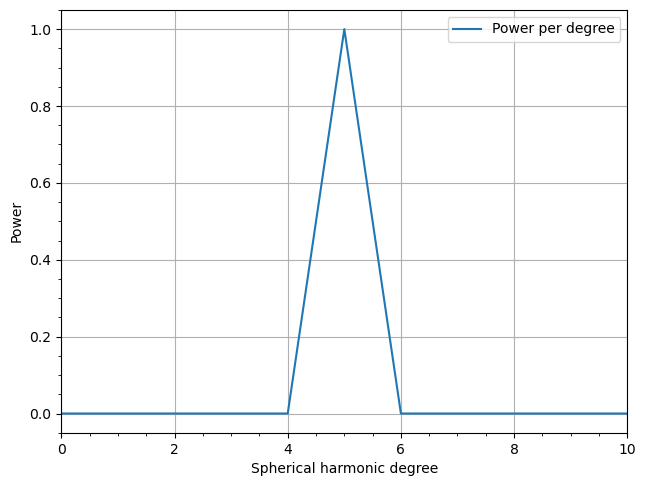

In [298]:
fig, ax = coeffs_l5m2.plot_spectrum(xscale='lin', yscale='lin',  lmax = 10, show=False)

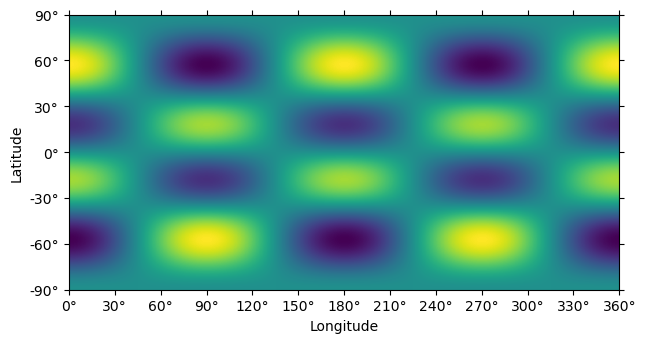

In [300]:
grid_l5m2 = coeffs_l5m2.expand(grid='DH')
fig, ax = grid_l5m2.plot(show=False)

In [302]:
grid_l5m2

  name = None
  kind = 'real'
  grid = 'DH'
  n = 402
  sampling = 1
  extend = True
  nlat = 403
  nlon = 403
  lmax = 200
  units = None

In [ ]:
# batch processing for images
from itertools import chain  
col_names =  [['image', 'cyst_index', 'cyst_size', 'cyst_r'], ['power_per_l'+i for i in map(str, range(lmax+1))], ['power_per_lm'+i for i in map(str, range(lmax+1))]]
col_names = list(chain(*col_names))  
#col_names

#CPoutDir = "../images_data/CPouts2"
for nm in os.listdir(CPoutDir):
    if "_C4_CystMask.tiff" in nm:
        #print(nm)
        df = pd.DataFrame(columns = col_names)
        #df
        fileName = nm.replace('_C4_CystMask.tiff','')
        
        outDir = os.path.join(path_results, str(fileName + '/'))
        if not os.path.exists(outDir):
            os.makedirs(outDir)
        
        #files += [nm]
        print(fileName)
        #make_composite_C5(newName, ImageDir, outDir)
        mask = imread(os.path.join(CPoutDir, str(fileName + "_C4_CystMask.tiff"))) # mask segmeted cysts
        C3 = imread(os.path.join(WTDir, str(fileName + "_C3.tif"))) # FoxA2, nuclei
        C2 = imread(os.path.join(WTDir, str(fileName + "_C2.tif"))) # Pax6, nuclei
        C4 = imread(os.path.join(WTDir, str(fileName + "_C4.tif"))) # Dapi, nuclei
        
        labels_mask, nb_cyst = measure.label(mask, return_num = True)
        
        # for each orgnoid
        for i in range(nb_cyst+1):
            if i > 0:
                
                cyst_select = np.where(labels_mask == i)
                cyst_index = i
                
                if cyst_select[0].size > 100: # orgnoid must > 100
                    # find the boundary of the orgnoid
                    [z, rows, columns] = np.where(labels_mask == cyst_index)
                    z1 = min(z)
                    z2 = max(z)
                    row1 = min(rows)
                    row2 = max(rows)
                    col1 = min(columns)
                    col2 = max(columns)
                
                    # crop the orgnoid and save foxa2 and dapi
                    xx = np.where(labels_mask == cyst_index, C3, 0)
                    newImage_foxa2 = xx[z1:z2, row1:row2, col1:col2]
                
                    xx = np.where(labels_mask == cyst_index, C4, 0)
                    newImage_dapi = xx[z1:z2, row1:row2, col1:col2]

                    xx = np.where(labels_mask == cyst_index, labels_mask, 0)
                    newImage_cyst = xx[z1:z2, row1:row2, col1:col2]
                
                    imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")), newImage_foxa2)
                    imsave(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")), newImage_dapi)
                    
                    del xx, newImage_dapi, newImage_cyst, newImage_foxa2, z1, z2, row1, row2, col1, col2
                    
                    # reload the dapi and foxa2 using vedo
                    vol_foxa2 = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_FoxA2_" + str(cyst_index)+ ".tif")))
                    vol_dapi = load(os.path.join(outDir, str(fileName + "_cyst_2_channel_dapi_"+ str(cyst_index) + ".tif")))
                
                    # the center and radius of organoid
                    pos = vol_dapi.center()
                    rmax = vol_dapi.diagonalSize()/2
                
                    # Compute voxel intensities
                    scalars = []
                    for th in np.linspace(0, np.pi, N, endpoint=False):
                        for ph in np.linspace(0, 2*np.pi, N, endpoint=False):
        
                            # compute sample points
                            p = spher2cart(rmax, th, ph)
        
                            samplePointsTmp = []
                            # making discretization more dense away from the center
                            p_tmp = p / (radiusDiscretisation-1)**expo
                        
                            for j in range(radiusDiscretisation):
                                SP = pos + p_tmp * (j**expo)
                                samplePointsTmp.append(SP)

                            # compute intensities
                            pb = probePoints(vol_foxa2, samplePointsTmp)

                            scalarsTmp = pb.getPointArray()
        
                            scalars.append(scalarsTmp.max())
                            del pb, scalarsTmp, samplePointsTmp
                            #gc.collect()


                    matrixOfIntensities = np.array(scalars)
                    #coeff = matrixOfIntensities
                    #matrixOfIntensities
                    #len(matrixOfIntensities)
                    formattedcoeff = np.reshape(matrixOfIntensities, (N, N))
                    
                    # remove the mean to reduce the l=0 contribution
                    formattedcoeff_norm = formattedcoeff - formattedcoeff.mean()
                    
                    del scalars, matrixOfIntensities, formattedcoeff
                    #gc.collect()
                    
                    SH = pyshtools.SHGrid.from_array(formattedcoeff_norm, grid = "DH")
                    clm = SH.expand(lmax_calc= lmax)
                    #grid_reco = clm.expand(lmax=lmax).to_array()  # cut "high frequency" components
                    grid = clm.expand(lmax = 20)
                    
                    Plot_intermediate = False
                    if Plot_intermediate: 
                        fig, ax = plt.subplots(1, 1)
                        ax.imshow(formattedcoeff, extent=(0, N, 0, N))
                        ax.set(xlabel='theta', ylabel='phi')
                        #plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity.pdf")))
                        plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2_intensity_" + str(cyst_index)+".pdf")))
                    
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        fig, ax = clm.plot_spectrum(show=False, lmax = 10, convention = 'power', unit = "per_lm")
                        plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_lm_" + str(cyst_index)+".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        fig, ax = clm.plot_spectrum(show=False, lmax = 10, convention = 'power', unit = "per_l")
                        plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_per_l_" + str(cyst_index)+ ".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        fig, ax = clm.plot_spectrum2d(show=False, lmax = 10)
                        plt.savefig(os.path.join(outDir, str(fileName + "_SH_power_2d_per_l_m_"+ str(cyst_index)+".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        
                        fig, ax = grid.plot(show=False)
                        plt.savefig(os.path.join(outDir, str(fileName + "_FoxA2Intensity_restored_with20Components_"+ str(cyst_index)+".pdf")))
                        plt.clf()
                        plt.close()
                        gc.collect()
                    
                        plt.close('all')
                        gc.collect();
                    
                    # save the SH power 
                    df.loc[len(df)] =  list(chain([fileName, cyst_index, cyst_select[0].size, rmax], 
                                              clm.spectrum(lmax = lmax, convention = 'power', unit = "per_lm"), 
                                              clm.spectrum(lmax = lmax, convention = 'power', unit = "per_l")))
                    
                    del SH, clm, grid, cyst_select, vol_foxa2, vol_dapi
                    #gc.collect()
                    
        df.to_csv(os.path.join(outDir, "Condion_echOrgnoid_SHspectrum_power.csv"), index=True, header=True)
        del mask, C2, C3, C4, df, labels_mask, nb_cyst
        #gc.collect()

In [158]:
#test = newImage_cyst/newImage_cyst.max() +  newImage_foxa2
test = newImage_dapi + newImage_foxa2

In [161]:
viewer = napari.Viewer()

# show images
viewer.add_image(cle.pull(newImage_cyst))
viewer.add_image(cle.pull(newImage_foxa2))
viewer.add_image(cle.pull(newImage_dapi))
viewer.add_image(cle.pull(test))


<Image layer 'test' at 0x319419df0>

In [159]:
# Use marching cubes to obtain the surface mesh of these ellipsoids
verts, faces, normals, values = measure.marching_cubes(volume = test, step_size = 1)

(0.0, 50.0)

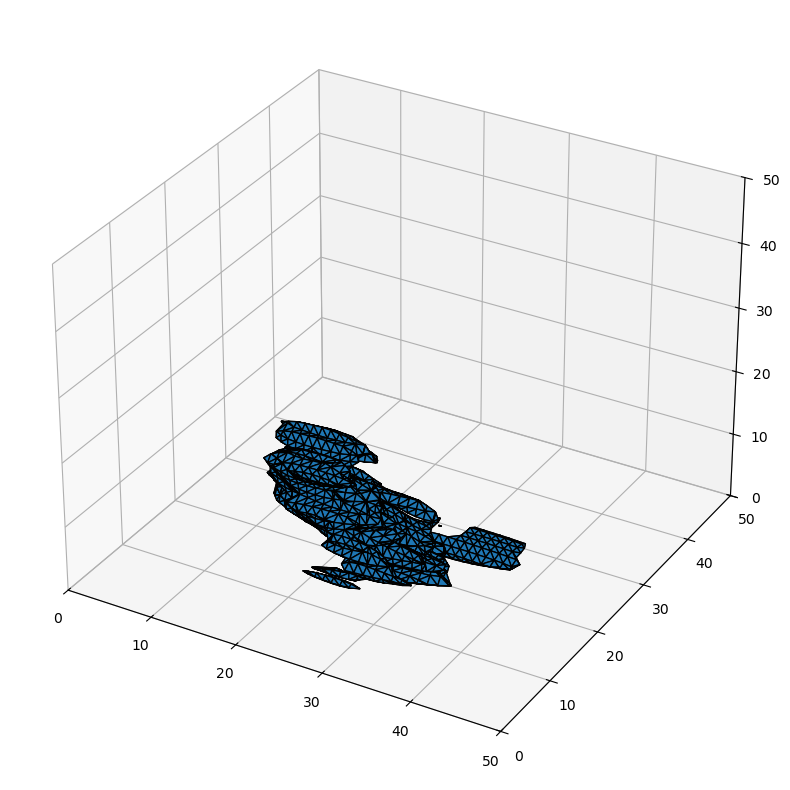

In [160]:
mesh = Poly3DCollection(verts[faces])

mesh.set_edgecolor('k')
fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')

# Fancy indexing: `verts[faces]` to generate a collection of triangles
ax.add_collection3d(mesh)

#ax.set_xlabel("x-axis: a = 6 per ellipsoid")
#ax.set_ylabel("y-axis: b = 10")
#ax.set_zlabel("z-axis: c = 16")
ax.set_xlim(0, 50)  # a = 6 (times two for 2nd ellipsoid)
ax.set_ylim(0, 50)  # b = 10
ax.set_zlim(0, 50)  # c = 16

#plt.tight_layout()
#plt.show()


In [121]:
newImage_foxa2.shape

(49, 47, 41)

(0.0, 50.0)

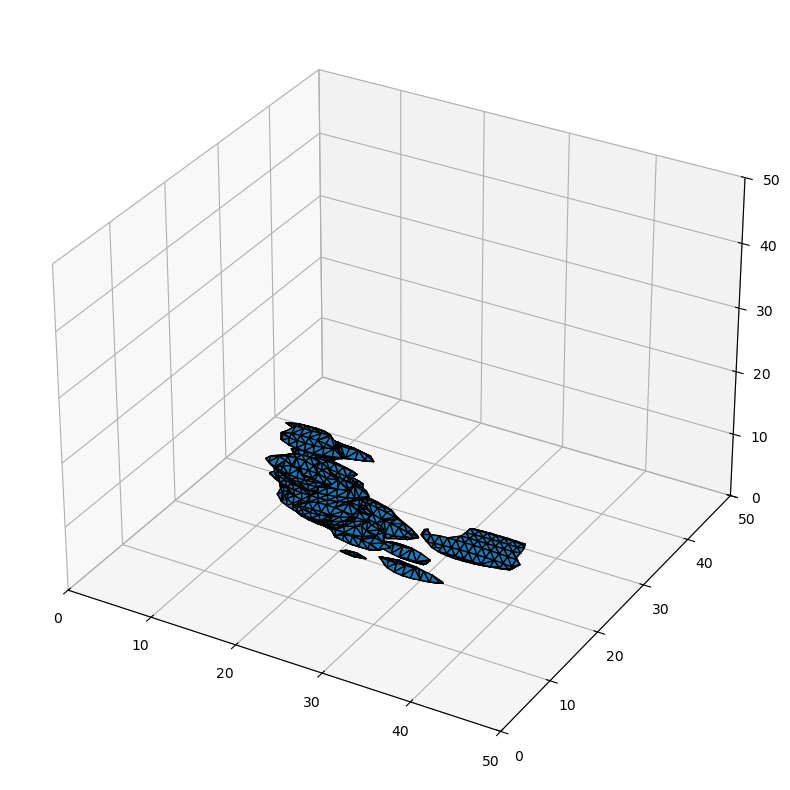

In [21]:
import napari
from napari.utils import nbscreenshot

In [18]:
## test marching cube algorith from scikit image 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from skimage import measure
from skimage.draw import ellipsoid

# Generate a level set about zero of two identical ellipsoids in 3D
ellip_base = ellipsoid(6, 10, 16, levelset=True)
ellip_double = np.concatenate((ellip_base[:-1, ...], ellip_base[2:, ...]), axis=0)

In [22]:
ellip_double.shape
#ellip_base.shape

(27, 23, 35)

In [24]:
viewer = napari.Viewer()
# show images
viewer.add_image(cle.pull(ellip_base))

<Image layer 'ellip_base' at 0x2b79c77c0>

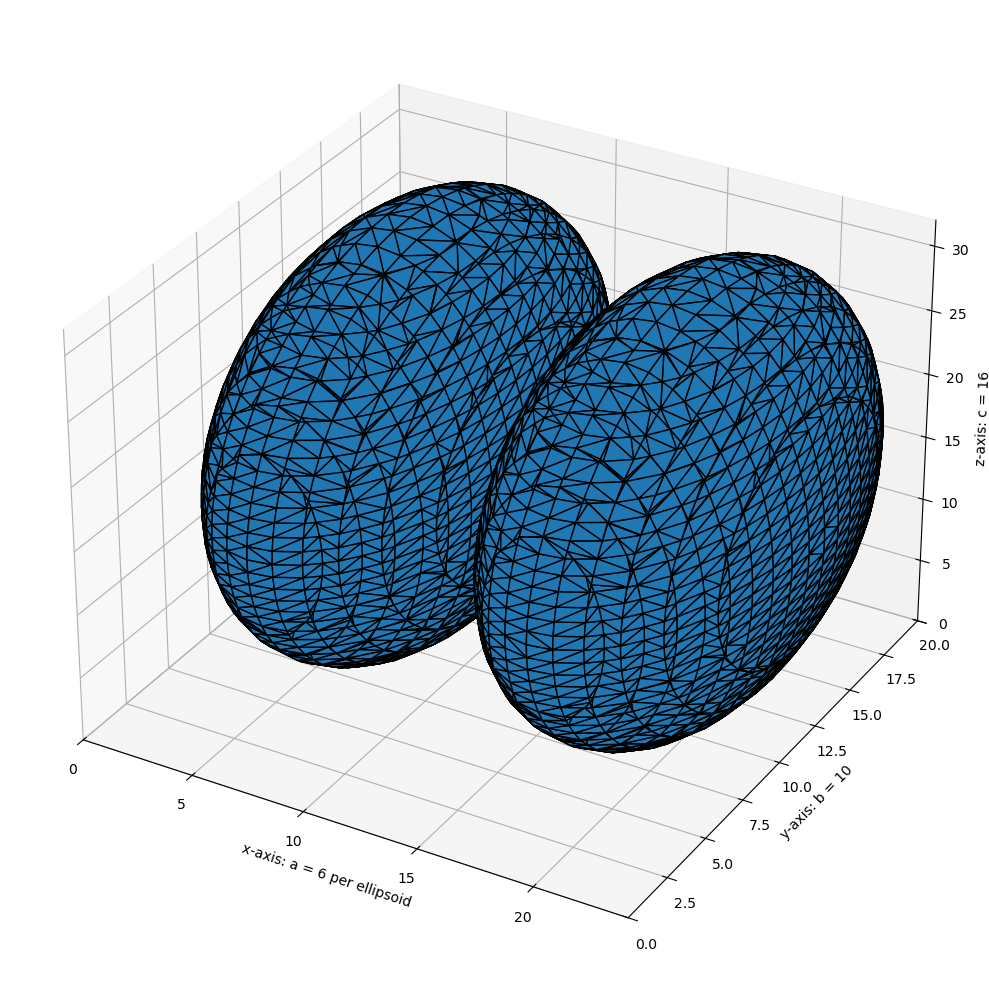

In [35]:
# Use marching cubes to obtain the surface mesh of these ellipsoids
verts, faces, normals, values = measure.marching_cubes(ellip_double, 0)

# Display resulting triangular mesh using Matplotlib. This can also be done
# with mayavi (see skimage.measure.marching_cubes docstring).
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Fancy indexing: `verts[faces]` to generate a collection of triangles
mesh = Poly3DCollection(verts[faces])
mesh.set_edgecolor('k')
ax.add_collection3d(mesh)

ax.set_xlabel("x-axis: a = 6 per ellipsoid")
ax.set_ylabel("y-axis: b = 10")
ax.set_zlabel("z-axis: c = 16")

ax.set_xlim(0, 24)  # a = 6 (times two for 2nd ellipsoid)
ax.set_ylim(0, 20)  # b = 10
ax.set_zlim(0, 32)  # c = 16

plt.tight_layout()
plt.show()


(20156,)

<Labels layer 'labels_mask' at 0x324cd2a90>

In [1]:
import numpy as np

from dipy.core.sphere import HemiSphere, Sphere, disperse_charges
from dipy.data import get_sphere
from dipy.reconst.shm import sf_to_sh, sh_to_sf
from dipy.sims.voxel import multi_tensor_odf


/Users/jingkui.wang/miniforge3/envs/image_env/lib/python3.9/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
from dipy.viz import actor, window

In [3]:
rng = np.random.default_rng()
n_pts = 64
theta = np.pi * rng.random(n_pts)
phi = 2 * np.pi * rng.random(n_pts)
hsph_initial = HemiSphere(theta=theta, phi=phi)


In [4]:
hsph_updated, potential = disperse_charges(hsph_initial, 5000)
sphere = Sphere(xyz=np.vstack((hsph_updated.vertices, -hsph_updated.vertices)))


In [5]:
mevals = np.array([[0.0015, 0.00015, 0.00015], [0.0015, 0.00015, 0.00015]])
angles = [(0, 0), (60, 0)]
odf = multi_tensor_odf(sphere.vertices, mevals, angles, [50, 50])

# Enables/disables interactive visualization
interactive = False

scene = window.Scene()
scene.SetBackground(1, 1, 1)

odf_actor = actor.odf_slicer(odf[None, None, None, :], sphere=sphere)
odf_actor.RotateX(90)
scene.add(odf_actor)

print("Saving illustration as symm_signal.png")
window.record(scene=scene, out_path="symm_signal.png", size=(300, 300))
if interactive:
    window.show(scene)

Saving illustration as symm_signal.png


In [6]:
# Change this value to try out other bases
sh_basis = "descoteaux07"
# Change this value to try other maximum orders
sh_order_max = 8

sh_coeffs = sf_to_sh(odf, sphere, sh_order_max=sh_order_max, basis_type=sh_basis)


In [7]:
high_res_sph = get_sphere(name="symmetric724").subdivide(n=2)
reconst = sh_to_sf(
    sh_coeffs, high_res_sph, sh_order_max=sh_order_max, basis_type=sh_basis
)

scene.clear()
odf_actor = actor.odf_slicer(reconst[None, None, None, :], sphere=high_res_sph)
odf_actor.RotateX(90)
scene.add(odf_actor)

print("Saving output as symm_reconst.png")
window.record(scene=scene, out_path="symm_reconst.png", size=(300, 300))
if interactive:
    window.show(scene)

Saving output as symm_reconst.png


In [8]:
mevals = np.array([[0.0015, 0.0003, 0.0003]])
angles = [(0, 0)]
odf2 = multi_tensor_odf(sphere.vertices, mevals, angles, [100])

n_pts_hemisphere = int(sphere.vertices.shape[0] / 2)
asym_odf = np.append(odf[:n_pts_hemisphere], odf2[n_pts_hemisphere:])

scene.clear()
odf_actor = actor.odf_slicer(asym_odf[None, None, None, :], sphere=sphere)
odf_actor.RotateX(90)
scene.add(odf_actor)

print("Saving output as asym_signal.png")
window.record(scene=scene, out_path="asym_signal.png", size=(300, 300))
if interactive:
    window.show(scene)

Saving output as asym_signal.png


In [9]:
sh_coeffs = sf_to_sh(asym_odf, sphere, sh_order_max=sh_order_max, basis_type=sh_basis)
reconst = sh_to_sf(
    sh_coeffs, high_res_sph, sh_order_max=sh_order_max, basis_type=sh_basis
)

scene.clear()
odf_actor = actor.odf_slicer(reconst[None, None, None, :], sphere=high_res_sph)
odf_actor.RotateX(90)
scene.add(odf_actor)

print("Saving output as asym_reconst.png")
window.record(scene=scene, out_path="asym_reconst.png", size=(300, 300))
if interactive:
    window.show(scene)

Saving output as asym_reconst.png


In [10]:
sh_coeffs = sf_to_sh(
    asym_odf, sphere, sh_order_max=sh_order_max, basis_type=sh_basis, full_basis=True
)
reconst = sh_to_sf(
    sh_coeffs,
    high_res_sph,
    sh_order_max=sh_order_max,
    basis_type=sh_basis,
    full_basis=True,
)

scene.clear()
odf_actor = actor.odf_slicer(reconst[None, None, None, :], sphere=high_res_sph)
odf_actor.RotateX(90)
scene.add(odf_actor)

print("Saving output as asym_reconst_full.png")
window.record(scene=scene, out_path="asym_reconst_full.png", size=(300, 300))
if interactive:
    window.show(scene)

Saving output as asym_reconst_full.png
